(meta_analysis_experiments)=
# Multiple Experiments and Bayesian Meta-analysis

:::{post} May 2026
:tags: experimentation, meta-analysis, hierarchical models, partial pooling, replication
:category: intermediate, reference
:author: Nathaniel Forde
:::

:::{figure} experimentation_triptych.jpeg
:name: experimentation-triptych
:width: 100%
:align: center

The experimentation lifecycle as a Bosch triptych. *Left, Bayesian Assurance:* before any data arrive, the planner reads possible effects from the prior and asks what the experiment will likely conclude. *Centre, Sensitivity Analysis:* a single experiment is wracked by the biases it cannot rule out, and the model is contorted to see which commitments its conclusion can survive. *Right, Meta-Analysis (this notebook):* many experiments are pooled through a hierarchy of levels into a synthesis that becomes the next plan's prior. Three panels, one posterior machinery.
:::

## The replication-as-evidence problem

Eight quarterly A/B tests of the same checkout-flow redesign, run across eight markets, return eight different point estimates. Two cross the conventional significance threshold; the other six do not. The product manager asks the natural question, "did it work?", and gets two incompatible defaults depending on which colleague answers: vote-counting ("four out of eight worked, so it's a wash"), or pool-everything ("the combined estimate is positive, so it works"). Both are mistakes. The vote-count discards the magnitude information in each estimate; the pool-everything pretends the markets are exchangeable in a way the evidence does not support. The honest answer requires a model that estimates between-market differences rather than assuming them away.

Each experiment speaks about one market. The hierarchy is what lets us hear all of them at once.

This notebook builds that model. The hierarchical Bayesian meta-analysis treats each experiment as a noisy estimate of its own market's true effect, and treats the per-market effects as draws from a population whose mean and variance are themselves the quantities of substantive interest {cite:p}`borenstein2009meta`, {cite:p}`higgins2009meta`. The structure is the one Rubin used for the 8-schools problem in 1981 {cite:p}`rubin1981estimation`, {cite:p}`gelman2013bayesian`, transposed to product experimentation. We develop it on a continuous outcome (revenue per visitor) and then re-run it on a binary outcome (conversion). This is the third of three notebooks on the lifecycle of a Bayesian experiment; see {ref}`assurance_planning` for the planning counterpart and {ref}`sensitivity_confounding` for the interpretation counterpart. Readers wanting a deeper view of the partial-pooling vocabulary should also consult the existing PyMC notebooks on {ref}`multilevel_modeling` and {ref}`hierarchical_partial_pooling`, which we treat as predecessors rather than re-derive.

:::{admonition} Where this lands in regulatory practice
:class: note

The hierarchical model here is the borrowing mechanism a regulator now describes by name. The FDA's 2026 draft guidance on Bayesian methodology in clinical trials presents subgroup analysis through a *one-way Bayesian hierarchical model* whose subgroup estimate is "a weighted average of its raw estimated treatment effect ... and the overall estimated treatment effect" {cite:p}`fda2026bayesian`, the shrinkage picture this notebook builds. The same guidance treats hierarchical models as the main way to borrow information across related trials by assuming the group parameters are drawn from a common distribution, which is the $\theta_k \sim \mathcal{N}(\mu, \tau)$ structure below. Borrowing across studies, and the use of one trial's synthesis as the next trial's prior, is the regulatory form of the lifecycle loop these three notebooks trace.
:::

In [1]:
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm

from scipy import stats

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
%config InlineBackend.figure_format = 'retina'
az.style.use("arviz-variat")
rng = np.random.default_rng(11)
RANDOM_SEED = 11

## Heterogeneity is not new: groups within a single study

The across-study problem looks novel, but its structure appears inside a single experiment whenever the treatment effect varies across user segments. It is worth meeting the problem on this familiar ground first, because the tool that solves it here is the tool we will carry across studies, and its classical name is the analysis of variance.

Consider one market's experiment broken out across six user segments. The redesign helps some segments more than others, and the per-segment treatment effects are themselves draws from a population. We give the section its own random generator so the across-study results later in the notebook are unaffected.

In [3]:
seg_rng = np.random.default_rng(2024)

SEG_NAMES = [
    "New / mobile",
    "New / desktop",
    "Returning / mobile",
    "Returning / desktop",
    "High-value",
    "Reactivated",
]
N_PER_SEGMENT = np.array([600, 600, 900, 900, 1400, 1400])  # visitors per segment
SEG_MU, SEG_TAU = 0.30, 0.50
BASELINE, SIGMA_OBS = 10.0, 4.0


def simulate_within_study_segments(seg_names, N_per_seg, seg_mu, seg_tau, baseline, sigma_obs, rng):
    true_effects = rng.normal(seg_mu, seg_tau, size=len(seg_names))
    rows = []
    for name, N_seg, eff in zip(seg_names, N_per_seg, true_effects):
        treat = rng.integers(0, 2, size=int(N_seg))
        revenue = baseline + eff * treat + rng.normal(0, sigma_obs, size=int(N_seg))
        rows.append(pd.DataFrame({"segment": name, "treatment": treat, "revenue": revenue}))
    return pd.concat(rows, ignore_index=True), true_effects


study_df, seg_true_effects = simulate_within_study_segments(
    SEG_NAMES, N_PER_SEGMENT, SEG_MU, SEG_TAU, BASELINE, SIGMA_OBS, seg_rng
)
study_df.head()

,segment,treatment,revenue
0,New / mobile,1,15.883319
1,New / mobile,0,14.339618
2,New / mobile,0,7.025209
3,New / mobile,0,13.596865
4,New / mobile,1,11.434889


The per-segment treatment effect is a difference of arm means; its standard error follows from the within-arm variances.

In [4]:
def segment_effect_estimates(df):
    recs = []
    for name, g in df.groupby("segment", sort=False):
        t = g.loc[g.treatment == 1, "revenue"]
        c = g.loc[g.treatment == 0, "revenue"]
        recs.append(
            {
                "segment": name,
                "d": t.mean() - c.mean(),
                "se": np.sqrt(t.var(ddof=1) / len(t) + c.var(ddof=1) / len(c)),
            }
        )
    return pd.DataFrame(recs)


seg_est = segment_effect_estimates(study_df)
seg_est.round(3)

,segment,d,se
0,New / mobile,0.614,0.338
1,New / desktop,0.869,0.334
2,Returning / mobile,1.243,0.251
3,Returning / desktop,-0.339,0.268
4,High-value,-0.912,0.215
5,Reactivated,0.229,0.212


The classical question "does the effect differ across segments?" is a test for the treatment-by-segment interaction, and the two-way analysis of variance answers it with an $F$-test. We compute it directly, as a comparison of nested least-squares fits, which keeps the dependency surface small and makes the variance decomposition explicit. The interaction row is the one to read.

In [5]:
def anova_two_way(df, outcome, factor, treatment):
    """Type-II two-way ANOVA via nested least-squares fits (treatment is binary)."""
    y = df[outcome].to_numpy(dtype=float)
    n = len(y)
    ones = np.ones((n, 1))
    A = pd.get_dummies(df[factor], drop_first=True).to_numpy(dtype=float)  # factor dummies
    B = pd.get_dummies(df[treatment], drop_first=True).to_numpy(dtype=float)  # treatment dummy
    AB = A * B  # interaction columns

    def fit(*blocks):
        X = np.hstack([ones, *blocks])
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        resid = y - X @ beta
        return float(resid @ resid), np.linalg.matrix_rank(X)

    rss_full, k_full = fit(A, B, AB)
    rss_add, k_add = fit(A, B)
    rss_A, k_A = fit(A)
    rss_B, k_B = fit(B)
    df_resid = n - k_full
    mse = rss_full / df_resid

    terms = {
        f"C({factor})": (rss_B - rss_add, k_add - k_B),
        f"C({treatment})": (rss_A - rss_add, k_add - k_A),
        f"C({factor}):C({treatment})": (rss_add - rss_full, k_full - k_add),
    }
    rows = [
        {
            "sum_sq": ss,
            "df": float(dof),
            "F": (ss / dof) / mse,
            "PR(>F)": stats.f.sf((ss / dof) / mse, dof, df_resid),
        }
        for ss, dof in terms.values()
    ]
    rows.append({"sum_sq": rss_full, "df": float(df_resid), "F": np.nan, "PR(>F)": np.nan})
    return pd.DataFrame(rows, index=list(terms) + ["Residual"])


anova_tbl = anova_two_way(study_df, "revenue", "segment", "treatment")
anova_tbl.round(3)

,sum_sq,df,F,PR(>F)
C(segment),402.260,5.0,5.057,0.00
C(treatment),23.888,1.0,1.502,0.22
C(segment):C(treatment),828.451,5.0,10.415,0.00
Residual,92081.361,5788.0,NaN,NaN


The interaction $F$-test reports whether heterogeneity is detectable; it does not estimate how large it is.

:::{admonition} Three numbers for heterogeneity
:class: note

Given per-group effect estimates $\hat d_k$ with standard errors $s_k$ and inverse-variance weights $w_k = 1/s_k^2$:

- **Cochran's $Q$** measures how far the estimates spread beyond what sampling noise alone would produce. It is $Q = \sum_k w_k (\hat d_k - \bar d)^2$, where $\bar d$ is the precision-weighted mean, and it is simply the inverse-variance-weighted version of the between-groups sum of squares from ANOVA. If every group shared one true effect, $Q$ would follow a $\chi^2$ distribution with $K-1$ degrees of freedom, so a $Q$ much larger than $K-1$ is evidence of real heterogeneity.
- **$I^2 = \max\!\big(0,\, (Q - (K-1))/Q\big)$** rescales $Q$ onto the unit interval: the share of the total variation in the estimates due to genuine between-group differences rather than sampling error. $I^2 = 0$ means the spread is all noise; $I^2 = 0.9$ means most of it is real.
- **The DerSimonian–Laird estimator** is the classical, non-Bayesian way to turn $Q$ into a point estimate of the between-group variance $\tau^2$. It is a method-of-moments calculation, and once $\hat\tau^2$ is in hand the random-effects pooled mean re-weights each group by $1/(s_k^2 + \hat\tau^2)$ instead of $1/s_k^2$, so noisy groups count for less and no single precise group dominates.

See {cite:p}`borenstein2009meta` for the full treatment and {cite:p}`higgins2009meta` for the random-effects model these statistics serve.
:::

In [6]:
d = seg_est["d"].values
s = seg_est["se"].values
w = 1.0 / s**2
d_fixed = np.sum(w * d) / np.sum(w)
se_fixed = np.sqrt(1.0 / np.sum(w))
df_q = len(d) - 1
Q = np.sum(w * (d - d_fixed) ** 2)
p_Q = stats.chi2.sf(Q, df_q)
I2 = max(0.0, (Q - df_q) / Q)
C_dl = np.sum(w) - np.sum(w**2) / np.sum(w)
tau2_DL = max(0.0, (Q - df_q) / C_dl)
w_re = 1.0 / (s**2 + tau2_DL)
mu_DL = np.sum(w_re * d) / np.sum(w_re)
se_DL = np.sqrt(1.0 / np.sum(w_re))

print(f"Cochran's Q = {Q:.2f}  (df = {df_q}, p = {p_Q:.3f})")
print(f"I² = {I2:.2f}   DerSimonian–Laird between-segment SD τ = {np.sqrt(tau2_DL):.3f}")

Cochran's Q = 53.38  (df = 5, p = 0.000)
I² = 0.91   DerSimonian–Laird between-segment SD τ = 0.807


The hierarchical Bayesian model is the same random-effects analysis of variance, with one difference that matters when the number of groups is small: it returns a posterior over $\tau$ rather than a single number. With only six segments $\tau$ is weakly identified, and the DerSimonian–Laird point estimate can collapse toward zero even when real heterogeneity is present; the posterior shows that uncertainty honestly instead of hiding it in a point.

In [7]:
coords_seg = {"segment": SEG_NAMES}
with pm.Model(coords=coords_seg) as segment_model:
    mu = pm.Normal("mu", mu=0.0, sigma=1.0)
    tau = pm.HalfNormal("tau", sigma=1.0)
    offset = pm.Normal("offset", mu=0.0, sigma=1.0, dims="segment")
    theta = pm.Deterministic("theta", mu + tau * offset, dims="segment")
    pm.Normal("d_obs", mu=theta, sigma=s, observed=d, dims="segment")
    idata_seg = pm.sample(
        draws=2000,
        tune=2000,
        chains=2,
        target_accept=0.95,
        random_seed=RANDOM_SEED,
        progressbar=False,
    )

NUTS[nutpie]: [mu, tau, offset]


In [8]:
mu_post = idata_seg.posterior["mu"]
tau_post = idata_seg.posterior["tau"]
comparison = pd.DataFrame(
    {
        "pooled effect": [d_fixed, mu_DL, float(mu_post.mean())],
        "se / sd": [se_fixed, se_DL, float(mu_post.std())],
        "between-segment τ": [0.0, np.sqrt(tau2_DL), float(tau_post.mean())],
    },
    index=[
        "Fixed-effect ANOVA (complete pooling)",
        "Random-effects ANOVA (DerSimonian–Laird)",
        "Hierarchical Bayes (partial pooling)",
    ],
)
comparison.round(3)

,pooled effect,se / sd,between-segment τ
Fixed-effect ANOVA (complete pooling),0.148,0.105,0.000
Random-effects ANOVA (DerSimonian–Laird),0.270,0.348,0.807
Hierarchical Bayes (partial pooling),0.238,0.355,0.872


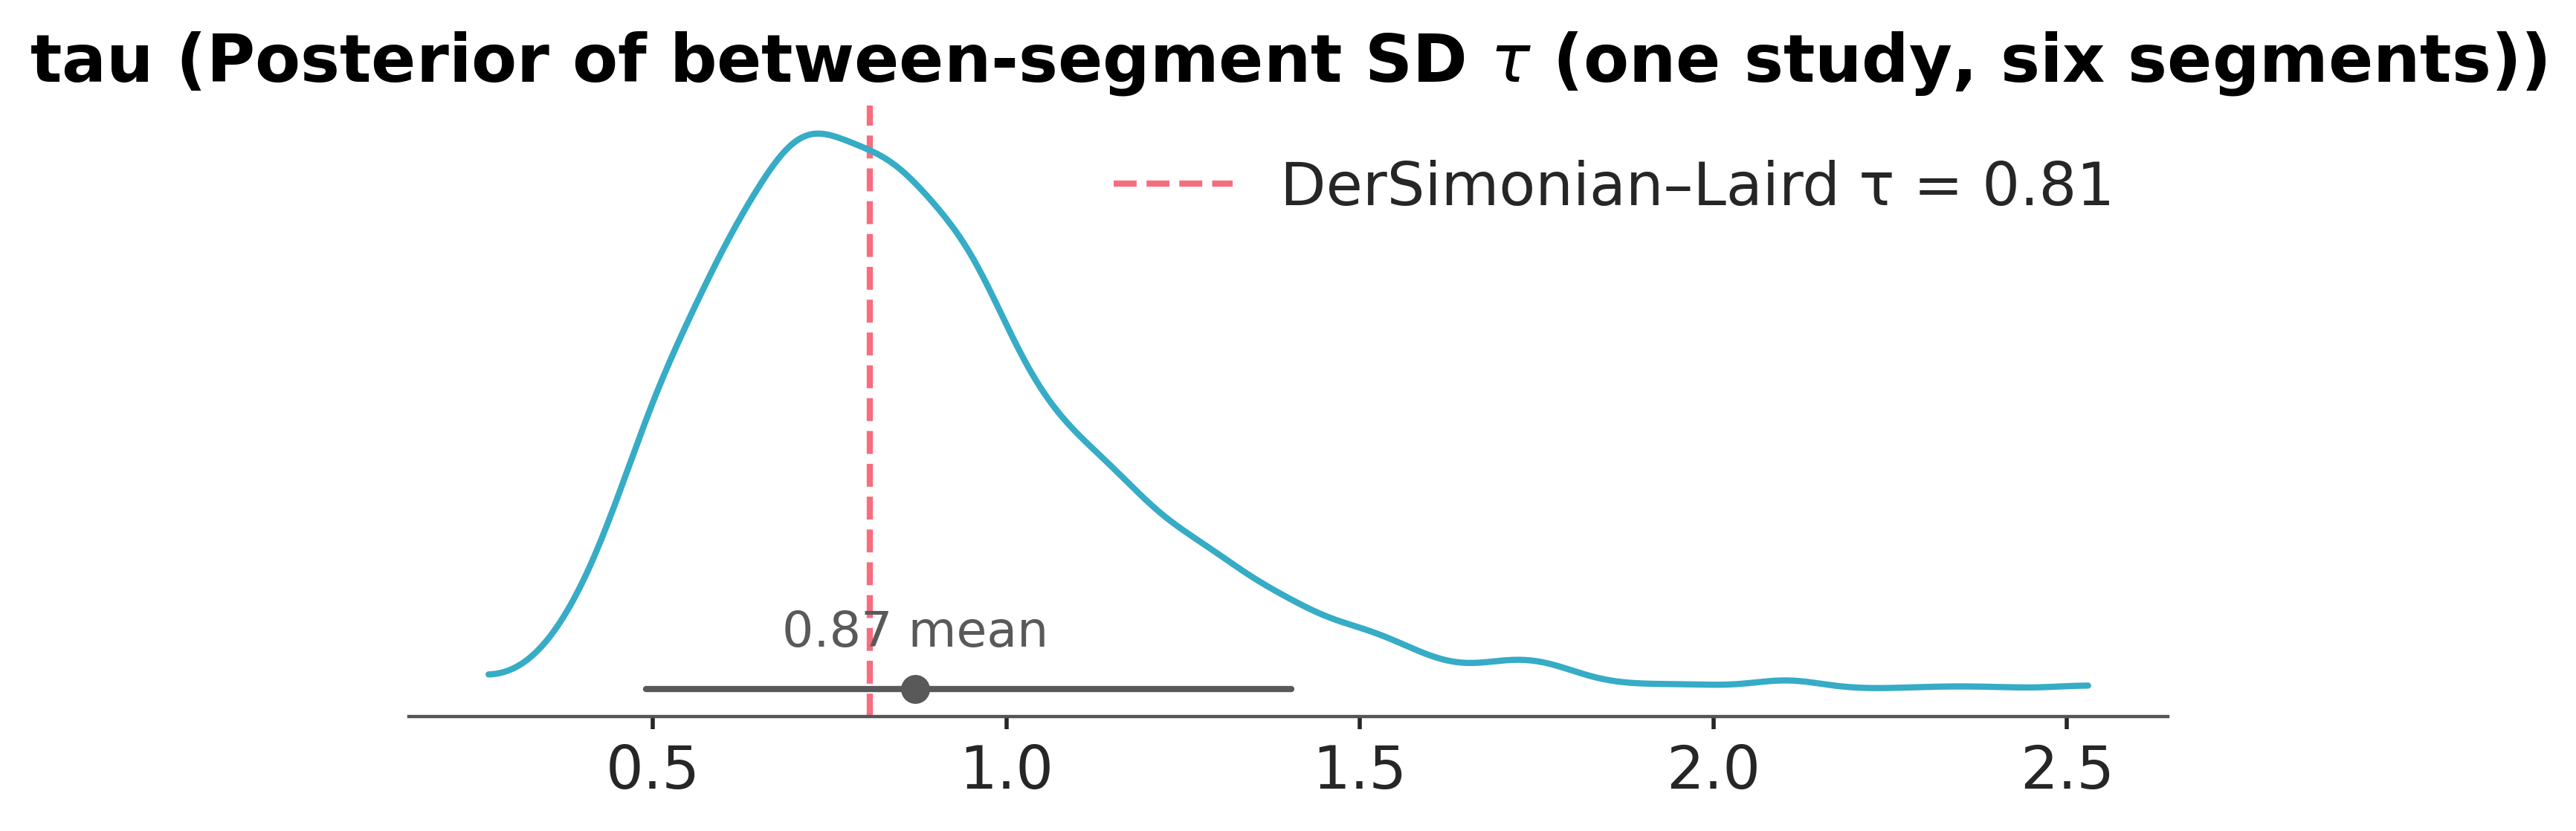

In [9]:
pc = az.plot_dist(
    idata_seg,
    var_names=["tau"],
    visuals={
        "title": {"text": r"Posterior of between-segment SD $\tau$ (one study, six segments)"}
    },
)
az.add_lines(
    pc,
    values=np.sqrt(tau2_DL),
    visuals={"ref_line": {"color": "C1", "label": f"DerSimonian–Laird τ = {np.sqrt(tau2_DL):.2f}"}},
)
pc.get_viz("plot").legend();

Three estimators, three commitments about how much the segments share. The fixed-effect ANOVA assumes one common effect and pools completely; the random-effects ANOVA admits between-segment variance and estimates it by moments; the hierarchical model carries that variance as a posterior. The grouping factor was the segment. Replace it with "study" and the model is untouched: meta-analysis is the random-effects analysis of variance with studies as the groups, and the index $k$ ranges over experiments rather than segments. The rest of this notebook makes exactly that substitution. Making that substitution is mechanical. What it reveals is substantive: once studies replace segments, τ becomes the quantity the replication programme was designed to estimate.

## The hierarchical re-framing

The model is the one we just fit, with markets in place of segments. Let $\theta_k$ be the true treatment effect in market $k$, and let $\hat d_k$ be the observed estimate from market $k$'s experiment with standard error $s_k$. The single-experiment view treats each $\hat d_k$ as the answer to its own question; vote-counting and pool-everything are degenerate cases of that view. The hierarchical view writes:

$$
\theta_k \sim \mathcal{N}(\mu, \tau), \qquad \hat d_k \mid \theta_k \sim \mathcal{N}(\theta_k, s_k),
$$

where $\mu$ is the population mean effect across markets and $\tau$ is the between-market standard deviation. $\mu$ tells the team what to expect on average; $\tau$ tells them how variable that expectation is across markets. Neither quantity is recoverable from any single experiment. Both are recoverable from the joint.

In [10]:
K = 8
TRUE_MU = 0.4
TRUE_TAU = 0.5
SIGMA_OBS = 4.0
MARKET_NAMES = [f"Market {chr(65 + i)}" for i in range(K)]
# Per-market sample sizes vary; smaller markets have noisier estimates, which
# is the regime where partial pooling does substantively visible work.
N_PER_MARKET = np.array([200, 250, 300, 350, 400, 500, 700, 1200])
meta_rng = np.random.default_rng(20)


def simulate_meta_dataset_gaussian(K, N_per_market, true_mu, true_tau, sigma_obs, rng):
    theta = rng.normal(true_mu, true_tau, size=K)
    d_hat = np.zeros(K)
    s = np.zeros(K)
    for k in range(K):
        N_k = int(N_per_market[k])
        y_A = rng.normal(10.0, sigma_obs, size=N_k)
        y_B = rng.normal(10.0 + theta[k], sigma_obs, size=N_k)
        d_hat[k] = y_B.mean() - y_A.mean()
        s[k] = np.sqrt(y_A.var(ddof=1) / N_k + y_B.var(ddof=1) / N_k)
    return theta, d_hat, s


true_theta, d_hat_obs, se_obs = simulate_meta_dataset_gaussian(
    K, N_PER_MARKET, TRUE_MU, TRUE_TAU, SIGMA_OBS, meta_rng
)
markets_df = pd.DataFrame(
    {
        "market": MARKET_NAMES,
        "N_per_arm": N_PER_MARKET,
        "true_theta": true_theta,
        "d_hat": d_hat_obs,
        "se": se_obs,
        "z_score": d_hat_obs / se_obs,
    }
)
markets_df.round(3)

,market,N_per_arm,true_theta,d_hat,se,z_score
0,Market A,200,0.220,0.483,0.423,1.143
1,Market B,250,1.002,0.998,0.359,2.782
2,Market C,300,1.098,1.383,0.330,4.189
3,Market D,350,0.559,0.493,0.296,1.663
4,Market E,400,0.607,0.438,0.277,1.581
5,Market F,500,0.155,0.101,0.255,0.395
6,Market G,700,-0.057,0.072,0.212,0.338
7,Market H,1200,-0.050,-0.001,0.163,-0.004


The per-market `z_score` column is what a frequentist replication exercise would consult: anything above 1.96 in absolute value counts as "significant", anything below does not. The columns disagree about how many markets "worked"; the underlying true effects disagree less. This is the gap the hierarchical model closes. The quantity no single experiment can recover is τ.

## No pooling, complete pooling, partial pooling

Three estimators reflect three commitments about how much the markets share. *No pooling* fits each market in isolation; the per-market estimate is $\hat d_k$. *Complete pooling* fits a single mean across all markets, treating them as draws from one distribution with no between-market variance. *Partial pooling* fits the hierarchical model above and lets the data weigh how exchangeable the markets are. The PyMC code below makes all three explicit so the shrinkage that distinguishes them becomes visible.

In [11]:
coords = {"market": MARKET_NAMES}

with pm.Model(coords=coords) as complete_model:
    mu_complete = pm.Normal("mu", mu=0.0, sigma=1.0)
    pm.Normal("d_hat", mu=mu_complete, sigma=se_obs, observed=d_hat_obs, dims="market")

with complete_model:
    idata_complete = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        target_accept=0.95,
        random_seed=RANDOM_SEED,
        progressbar=False,
    )

with pm.Model(coords=coords) as partial_model:
    mu = pm.Normal("mu", mu=0.0, sigma=1.0)
    tau = pm.HalfNormal("tau", sigma=1.0)
    theta_offset = pm.Normal("theta_offset", mu=0.0, sigma=1.0, dims="market")
    theta = pm.Deterministic("theta", mu + tau * theta_offset, dims="market")
    pm.Normal("d_hat", mu=theta, sigma=se_obs, observed=d_hat_obs, dims="market")

with partial_model:
    idata_partial = pm.sample(
        draws=2000,
        tune=2000,
        chains=2,
        target_accept=0.95,
        random_seed=RANDOM_SEED,
        progressbar=False,
    )

NUTS[nutpie]: [mu]
NUTS[nutpie]: [mu, tau, theta_offset]


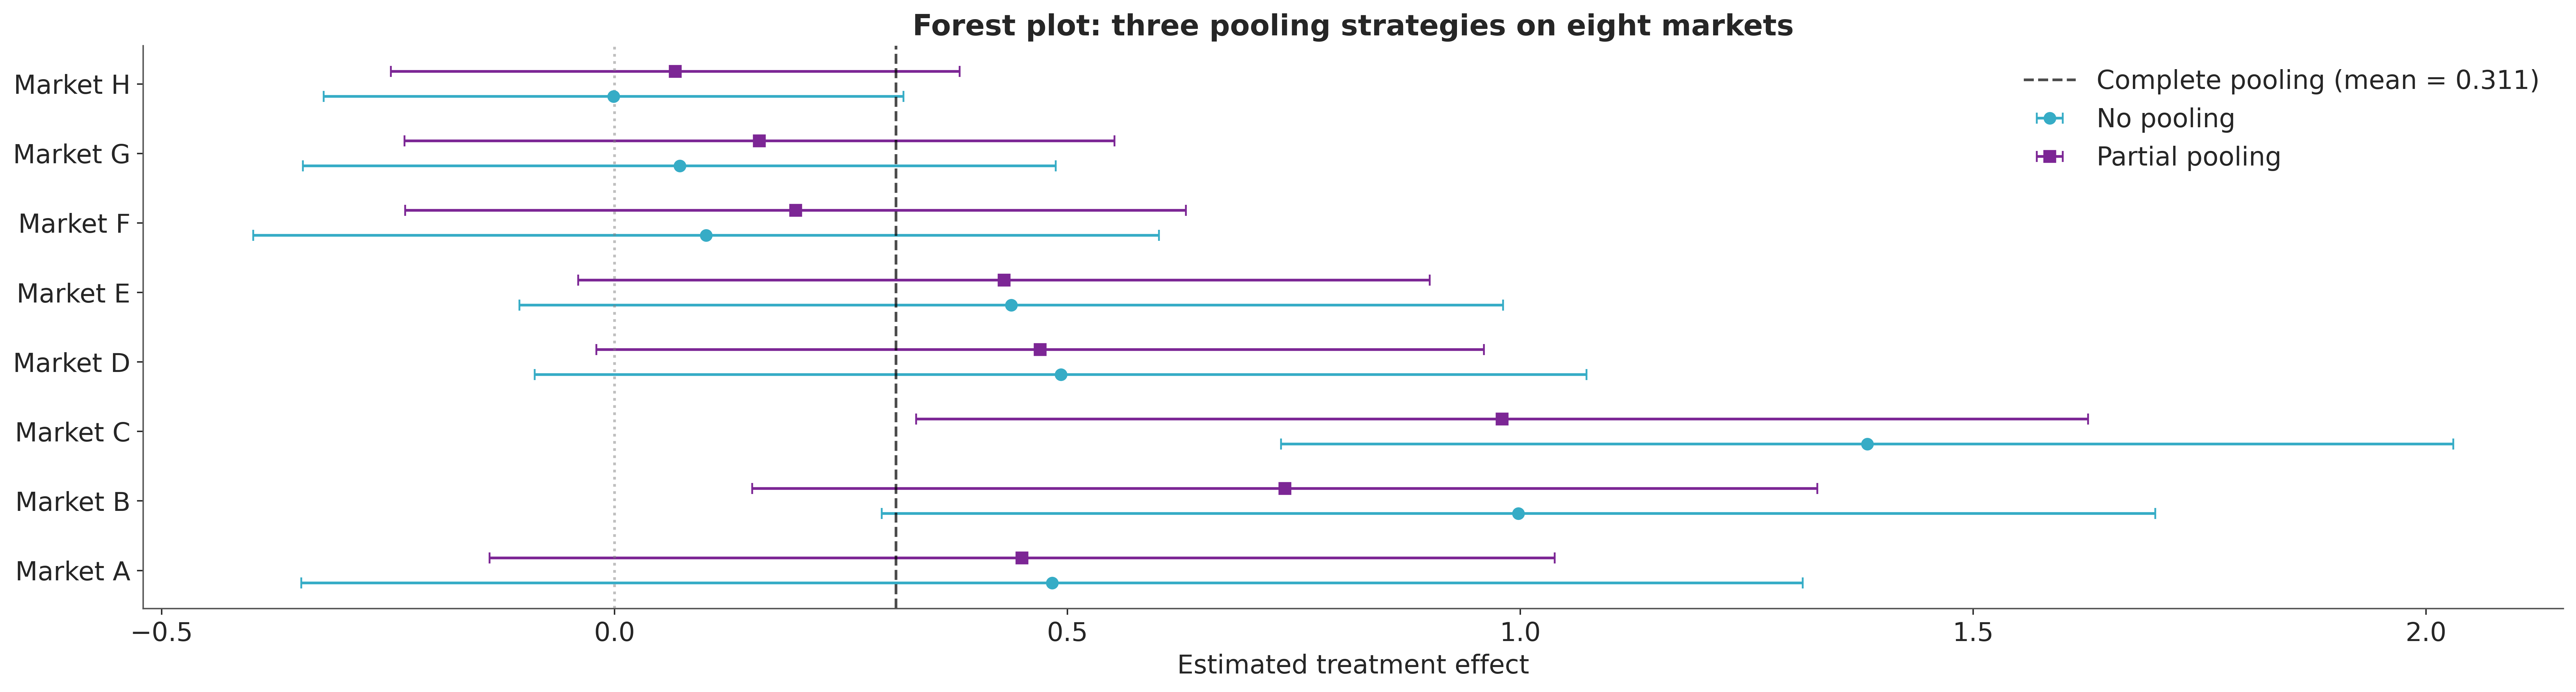

In [12]:
no_pool_mean = d_hat_obs
no_pool_se = se_obs
complete_pool_mean = idata_complete.posterior["mu"].mean().item()
complete_pool_se = idata_complete.posterior["mu"].std().item()
partial_pool_summary = az.summary(idata_partial, var_names=["theta"], kind="stats")
partial_pool_mean = partial_pool_summary["mean"].values.astype(float)
partial_pool_sd = partial_pool_summary["sd"].values.astype(float)

forest = pd.DataFrame(
    {
        "market": MARKET_NAMES,
        "no_pool_mean": no_pool_mean,
        "no_pool_lo": no_pool_mean - 1.96 * no_pool_se,
        "no_pool_hi": no_pool_mean + 1.96 * no_pool_se,
        "partial_mean": partial_pool_mean,
        "partial_lo": partial_pool_mean - 1.96 * partial_pool_sd,
        "partial_hi": partial_pool_mean + 1.96 * partial_pool_sd,
    }
).round(3)

fig, ax = plt.subplots(figsize=(20, 5.5))
y_pos = np.arange(K)
ax.errorbar(
    forest["no_pool_mean"],
    y_pos - 0.18,
    xerr=[
        forest["no_pool_mean"] - forest["no_pool_lo"],
        forest["no_pool_hi"] - forest["no_pool_mean"],
    ],
    fmt="o",
    color="C0",
    label="No pooling",
    capsize=3,
)
ax.errorbar(
    forest["partial_mean"],
    y_pos + 0.18,
    xerr=[
        forest["partial_mean"] - forest["partial_lo"],
        forest["partial_hi"] - forest["partial_mean"],
    ],
    fmt="s",
    color="C3",
    label="Partial pooling",
    capsize=3,
)
ax.axvline(
    complete_pool_mean,
    color="black",
    linestyle="--",
    alpha=0.7,
    label=f"Complete pooling (mean = {complete_pool_mean:.3f})",
)
ax.axvline(0.0, color="grey", linestyle=":", alpha=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(MARKET_NAMES)
ax.set_xlabel("Estimated treatment effect")
ax.set_title("Forest plot: three pooling strategies on eight markets")
ax.legend(loc="upper right", bbox_to_anchor=(1.0, 1.0), framealpha=0.95)
plt.tight_layout();

The partial-pooling estimates are pulled toward the population mean: the canonical *shrinkage* picture {cite:p}`gelman2006multilevel`, {cite:p}`gelman2020regression`. The pull is strongest for the markets whose individual estimates are noisiest (widest no-pooling intervals) or most extreme; it is weakest for markets whose estimates are tight and central. This is the data-driven version of "borrowing strength" that vote-counting cannot do and complete-pooling does only by force.

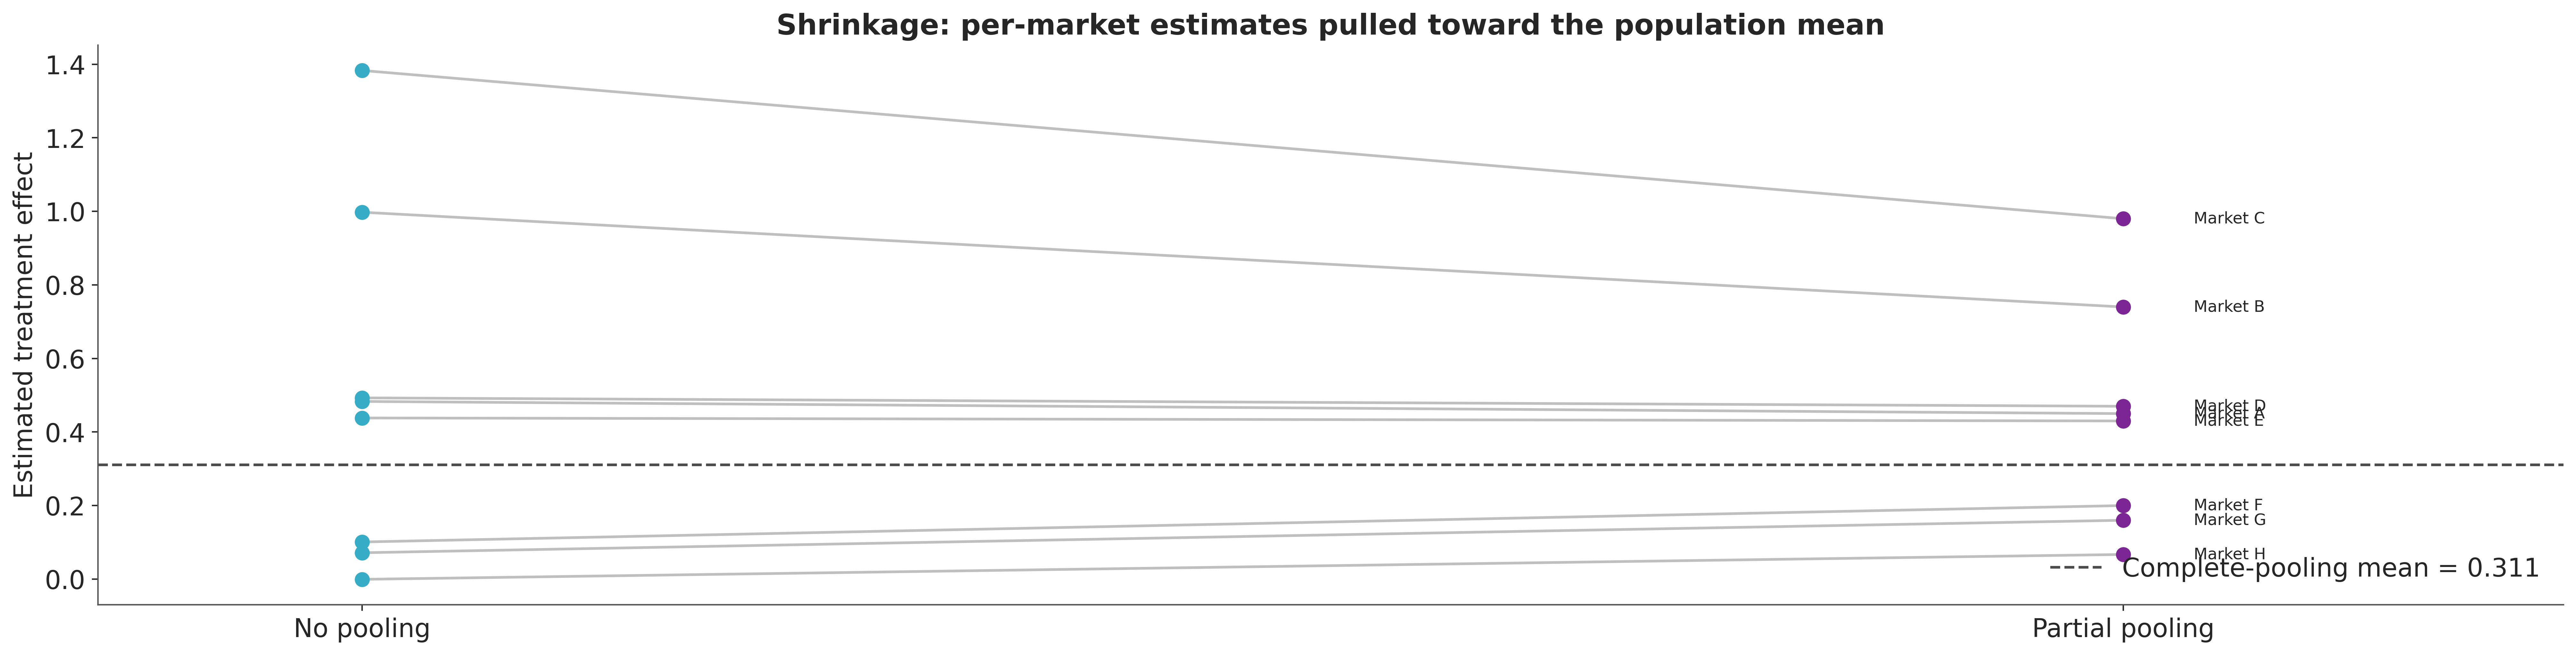

In [13]:
fig, ax = plt.subplots(figsize=(20, 5))
for k in range(K):
    ax.plot([0, 1], [no_pool_mean[k], partial_pool_mean[k]], color="grey", alpha=0.5, zorder=1)
    ax.scatter(0, no_pool_mean[k], color="C0", zorder=3, s=55)
    ax.scatter(1, partial_pool_mean[k], color="C3", zorder=3, s=55)
    ax.text(1.04, partial_pool_mean[k], MARKET_NAMES[k], ha="left", va="center", fontsize=9)
ax.axhline(
    complete_pool_mean,
    color="black",
    linestyle="--",
    alpha=0.7,
    label=f"Complete-pooling mean = {complete_pool_mean:.3f}",
)
ax.set_xticks([0, 1])
ax.set_xticklabels(["No pooling", "Partial pooling"])
ax.set_xlim(-0.15, 1.25)
ax.set_ylabel("Estimated treatment effect")
ax.set_title("Shrinkage: per-market estimates pulled toward the population mean")
ax.legend(loc="lower right");

### The substance lives in $\tau$

The hierarchical model returns two population-level quantities, and the conventional reporting habit of leading with $\mu$ obscures the more important one. The posterior of $\tau$, the between-market standard deviation of true effects, is what tells the team how transportable any single result is to a new context. A small $\tau$ means the markets are nearly exchangeable, and the experiment generalises cleanly; a large $\tau$ means the markets are heterogeneous, and the next market is a meaningfully new experiment. Reporting only $\mu$ collapses this into a point and hides the variability that the next stakeholder will live with.

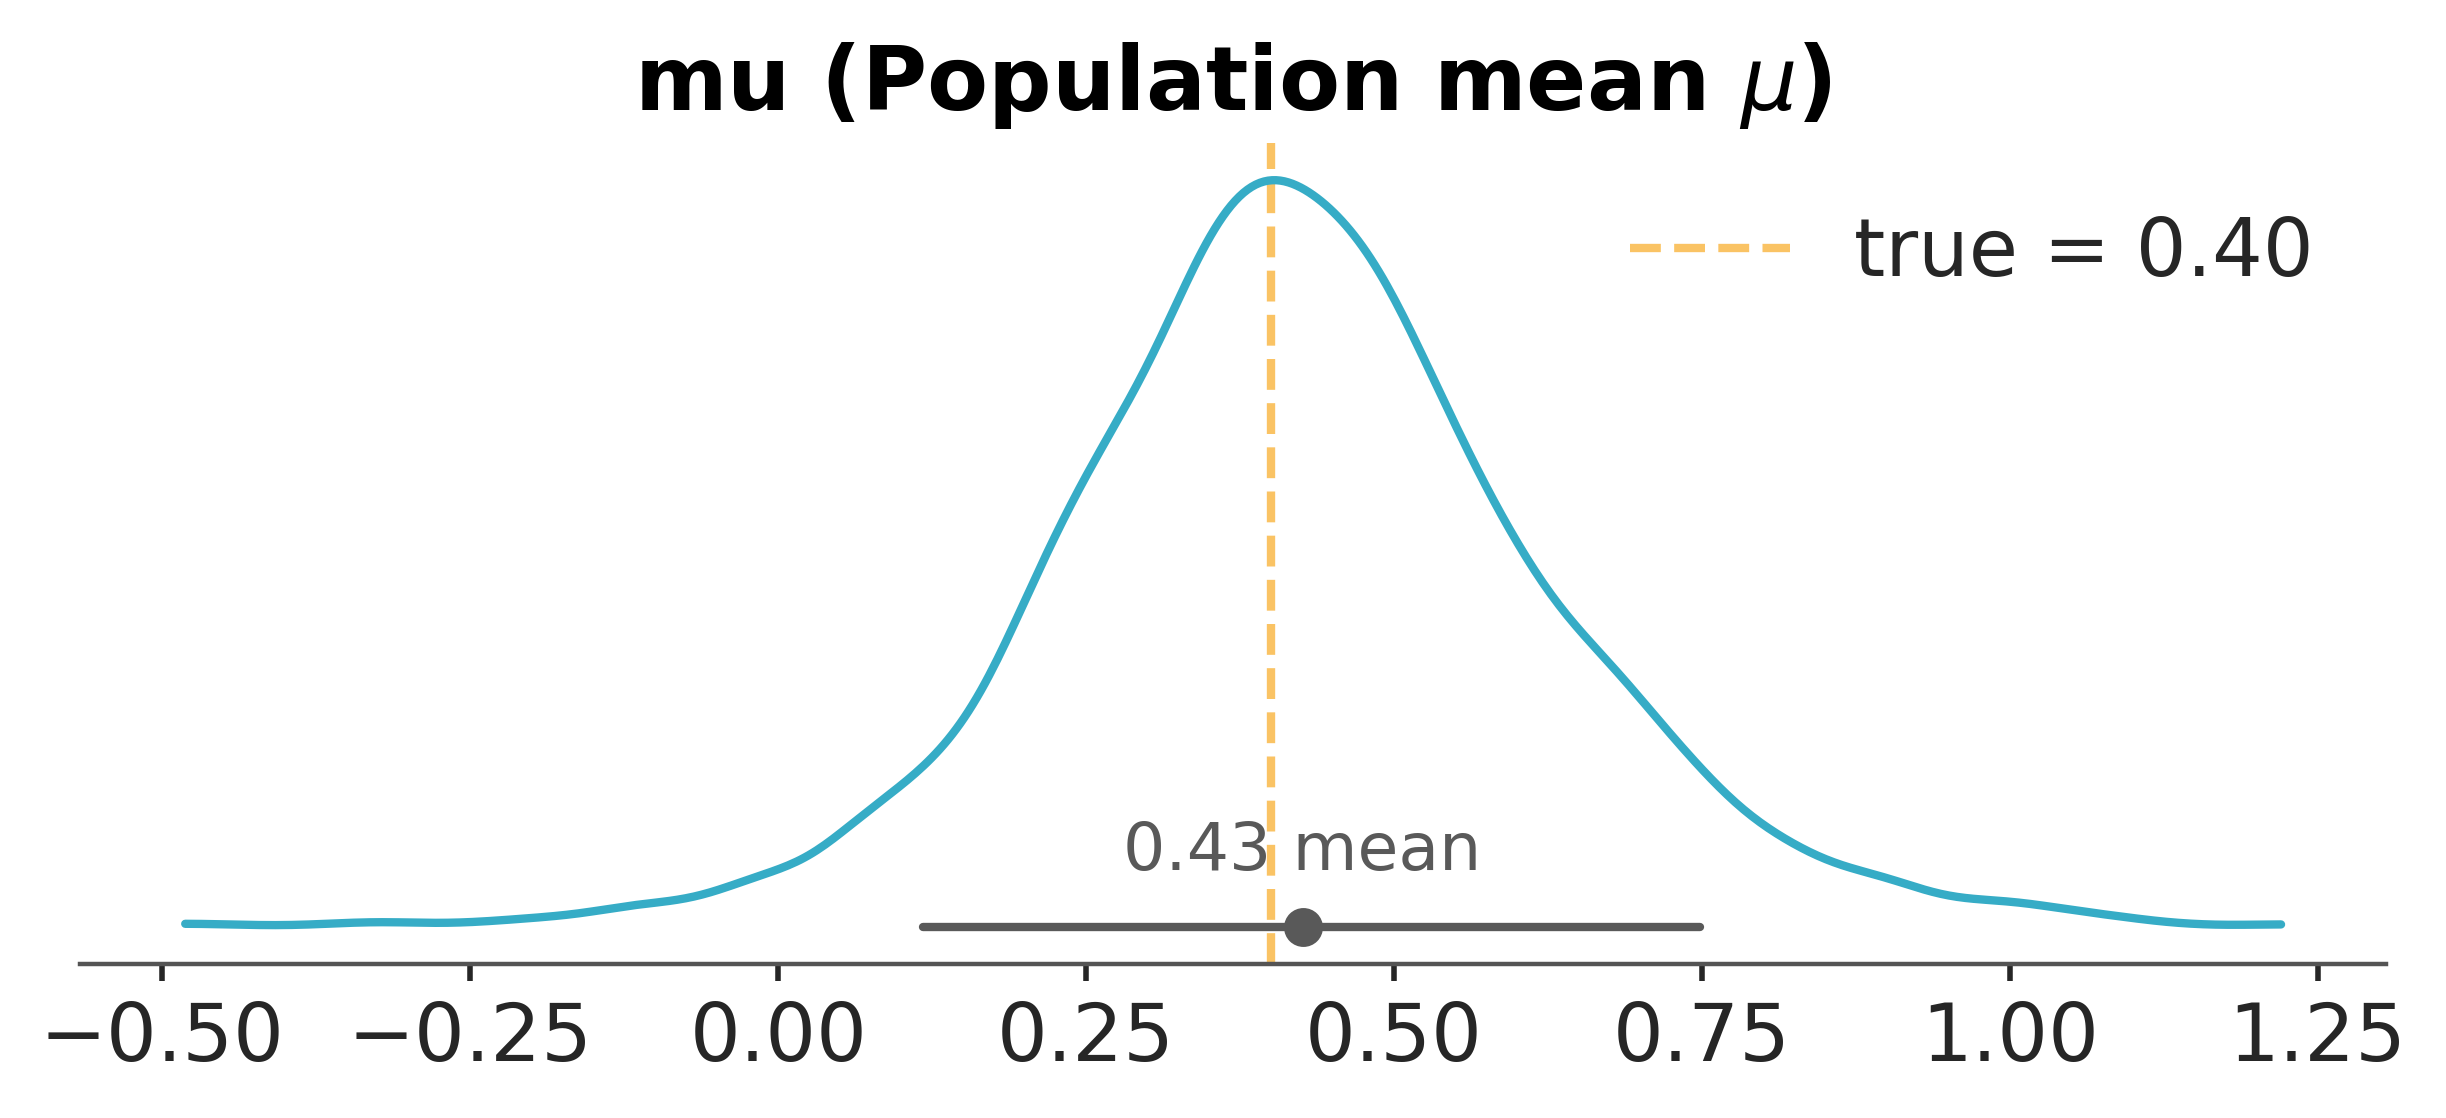

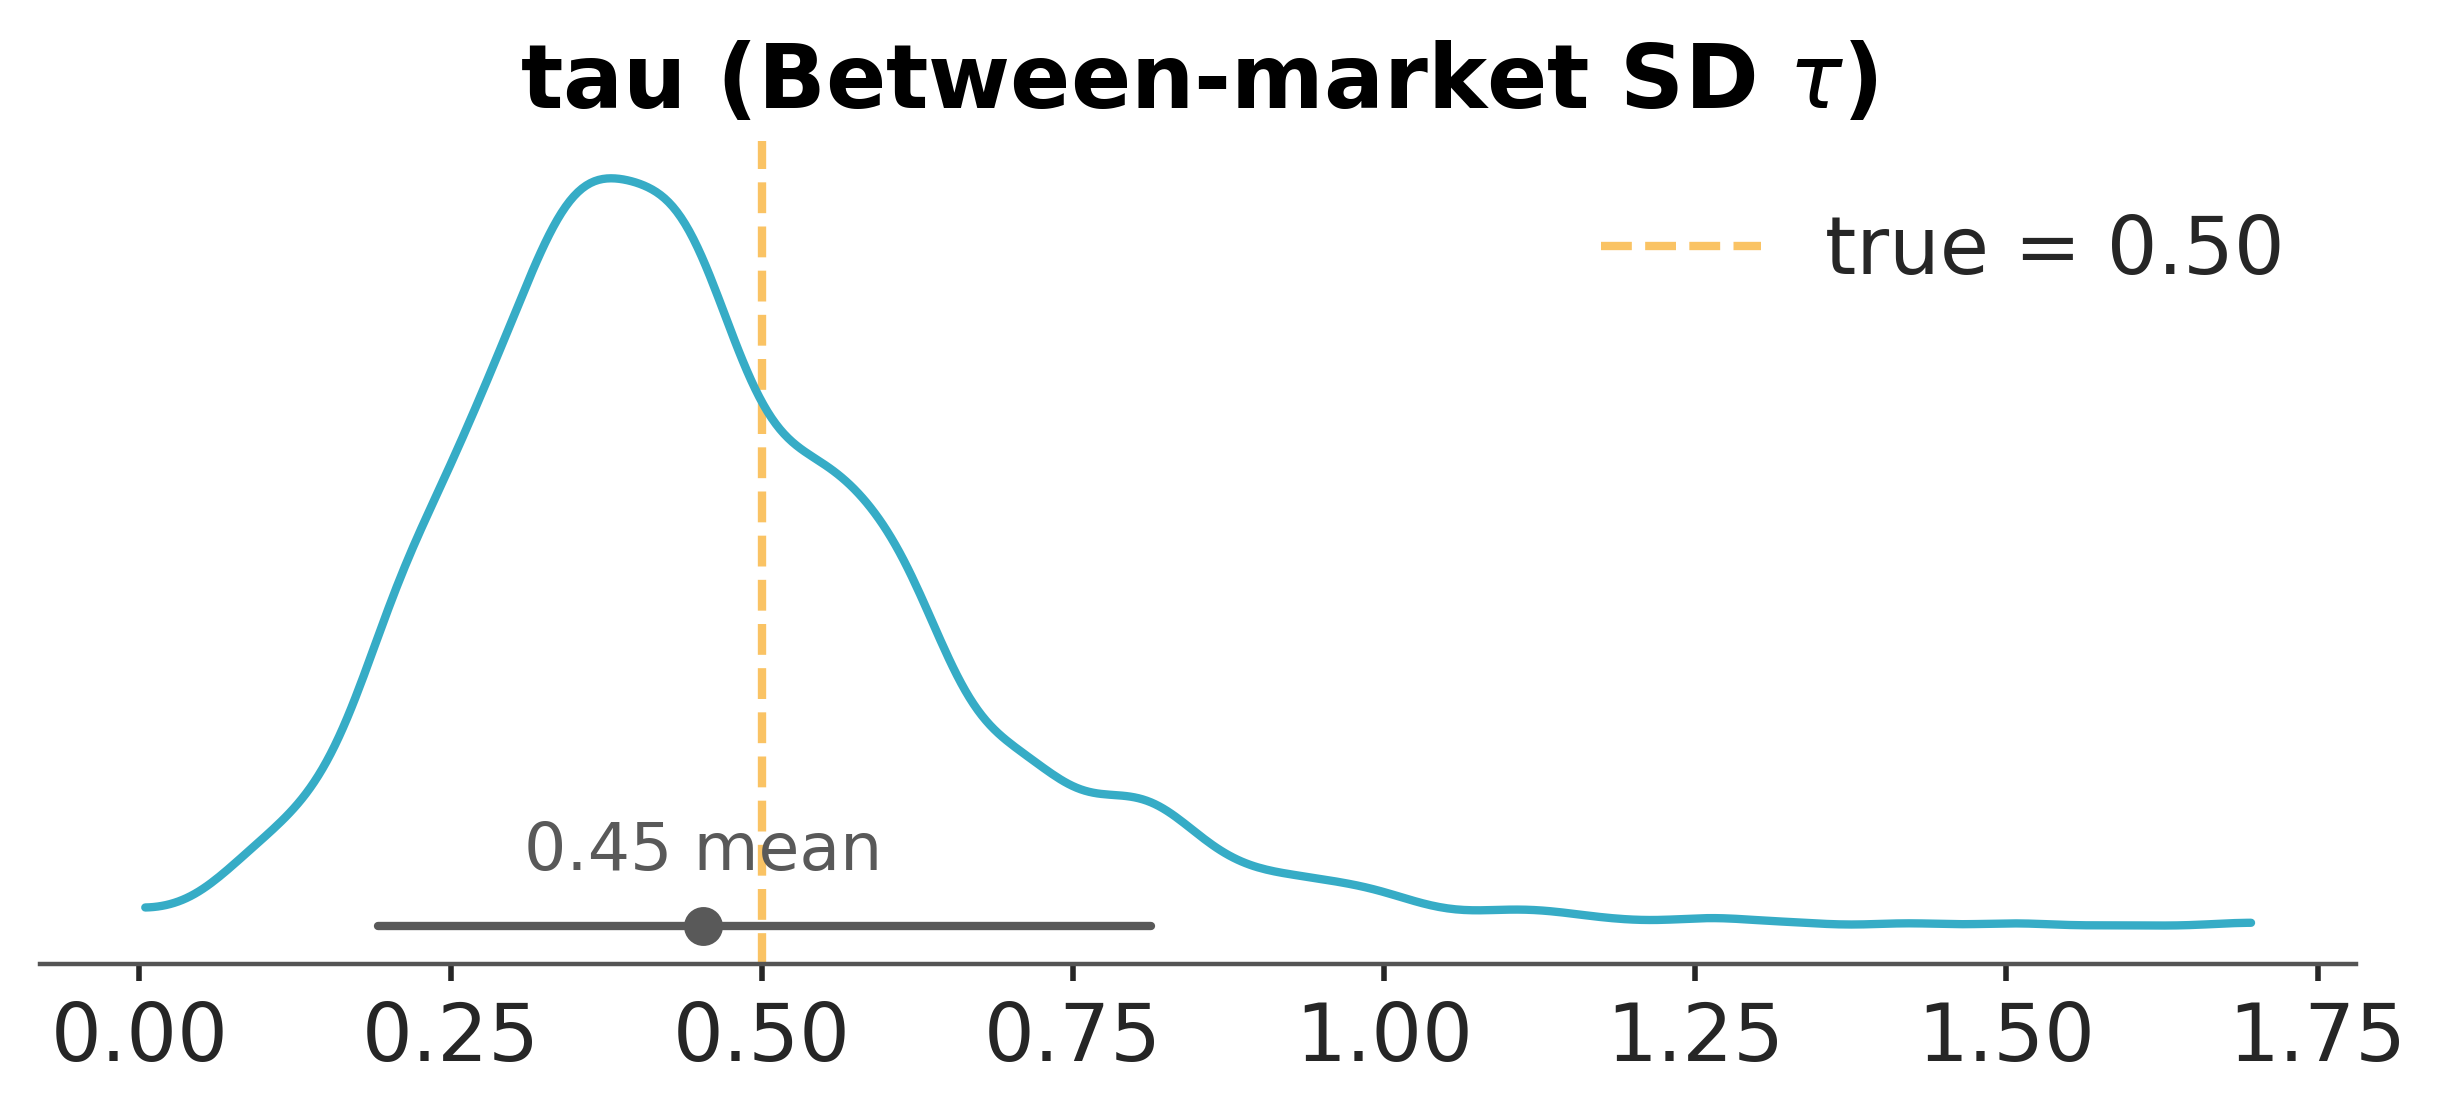

In [14]:
pc_mu = az.plot_dist(
    idata_partial,
    var_names=["mu"],
    visuals={"title": {"text": r"Population mean $\mu$"}},
)
az.add_lines(
    pc_mu,
    values=TRUE_MU,
    visuals={"ref_line": {"color": "C2", "label": f"true = {TRUE_MU:.2f}"}},
)
pc_mu.get_viz("plot").legend()

pc_tau = az.plot_dist(
    idata_partial,
    var_names=["tau"],
    visuals={"title": {"text": r"Between-market SD $\tau$"}},
)
az.add_lines(
    pc_tau,
    values=TRUE_TAU,
    visuals={"ref_line": {"color": "C2", "label": f"true = {TRUE_TAU:.2f}"}},
)
pc_tau.get_viz("plot").legend();

The posterior of $\tau$ is concentrated well away from zero, which is itself the result of substantive interest: the eight markets disagree about the size of the treatment effect in a way the data demand be respected. The conversion-rate version tells the same story, as we confirm next.

## The same machinery on a binary outcome

The conversion-rate version repeats the structure on the log-odds scale. Each market $k$ has its own baseline rate and its own treatment log-odds effect $\theta_k$; the population sits a level above ({cite:p}`carpenter2016hierarchical`).

In [15]:
TRUE_MU_LOGIT = 0.20
TRUE_TAU_LOGIT = 0.25
# Dedicated generator for the binary arm (as with `meta_rng`): keeps this section
# reproducible on its own and unaffected by the Gaussian arm's draws.
bern_rng = np.random.default_rng(2024)
BASELINE_RATES = bern_rng.beta(20, 180, size=K)


def simulate_meta_dataset_bernoulli(
    K, N_per_market, baseline_rates, true_mu_logit, true_tau_logit, rng
):
    from scipy.special import expit, logit

    theta = rng.normal(true_mu_logit, true_tau_logit, size=K)
    n_A = np.zeros(K, dtype=int)
    n_B = np.zeros(K, dtype=int)
    for k in range(K):
        p_A_k = baseline_rates[k]
        p_B_k = expit(logit(p_A_k) + theta[k])
        n_A[k] = rng.binomial(int(N_per_market[k]), p_A_k)
        n_B[k] = rng.binomial(int(N_per_market[k]), p_B_k)
    return theta, n_A, n_B


true_theta_bern, n_A_obs, n_B_obs = simulate_meta_dataset_bernoulli(
    K, N_PER_MARKET, BASELINE_RATES, TRUE_MU_LOGIT, TRUE_TAU_LOGIT, bern_rng
)

In [16]:
with pm.Model(coords=coords) as partial_bern_model:
    mu_logit = pm.Normal("mu", mu=0.0, sigma=0.5)
    tau_logit = pm.HalfNormal("tau", sigma=0.5)
    theta_offset = pm.Normal("theta_offset", mu=0.0, sigma=1.0, dims="market")
    theta = pm.Deterministic("theta", mu_logit + tau_logit * theta_offset, dims="market")
    baseline_logit = pm.Normal("baseline_logit", mu=-2.0, sigma=1.0, dims="market")
    p_A = pm.Deterministic("p_A", pm.math.invlogit(baseline_logit), dims="market")
    p_B = pm.Deterministic("p_B", pm.math.invlogit(baseline_logit + theta), dims="market")
    pm.Binomial("obs_A", n=N_PER_MARKET, p=p_A, observed=n_A_obs, dims="market")
    pm.Binomial("obs_B", n=N_PER_MARKET, p=p_B, observed=n_B_obs, dims="market")

with partial_bern_model:
    idata_partial_bern = pm.sample(
        draws=2000,
        tune=2000,
        chains=2,
        target_accept=0.95,
        random_seed=RANDOM_SEED,
        progressbar=False,
    )

NUTS[nutpie]: [mu, tau, theta_offset, baseline_logit]


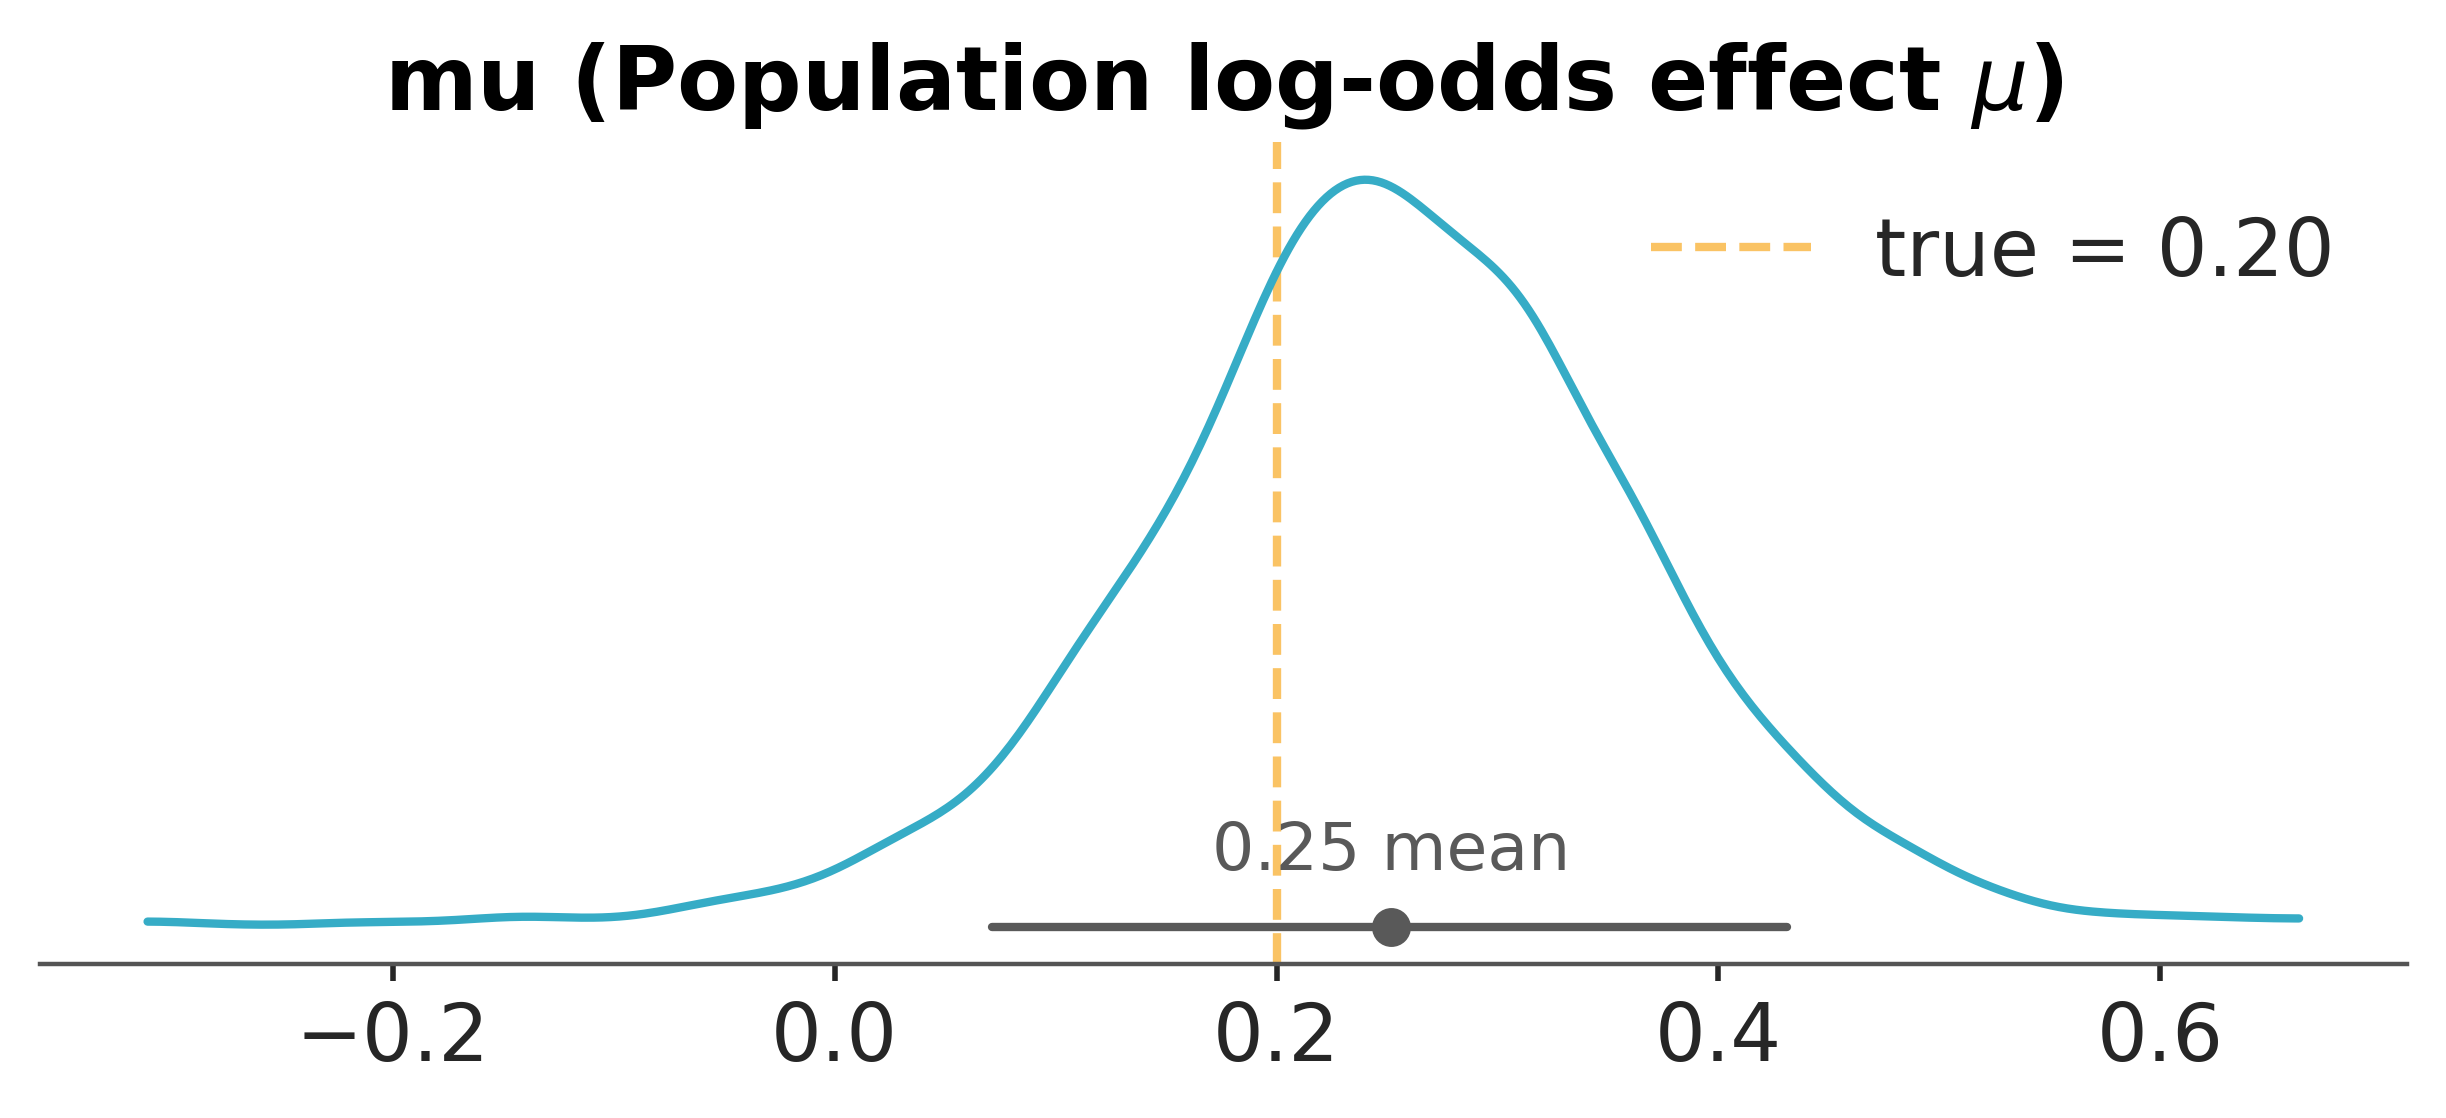

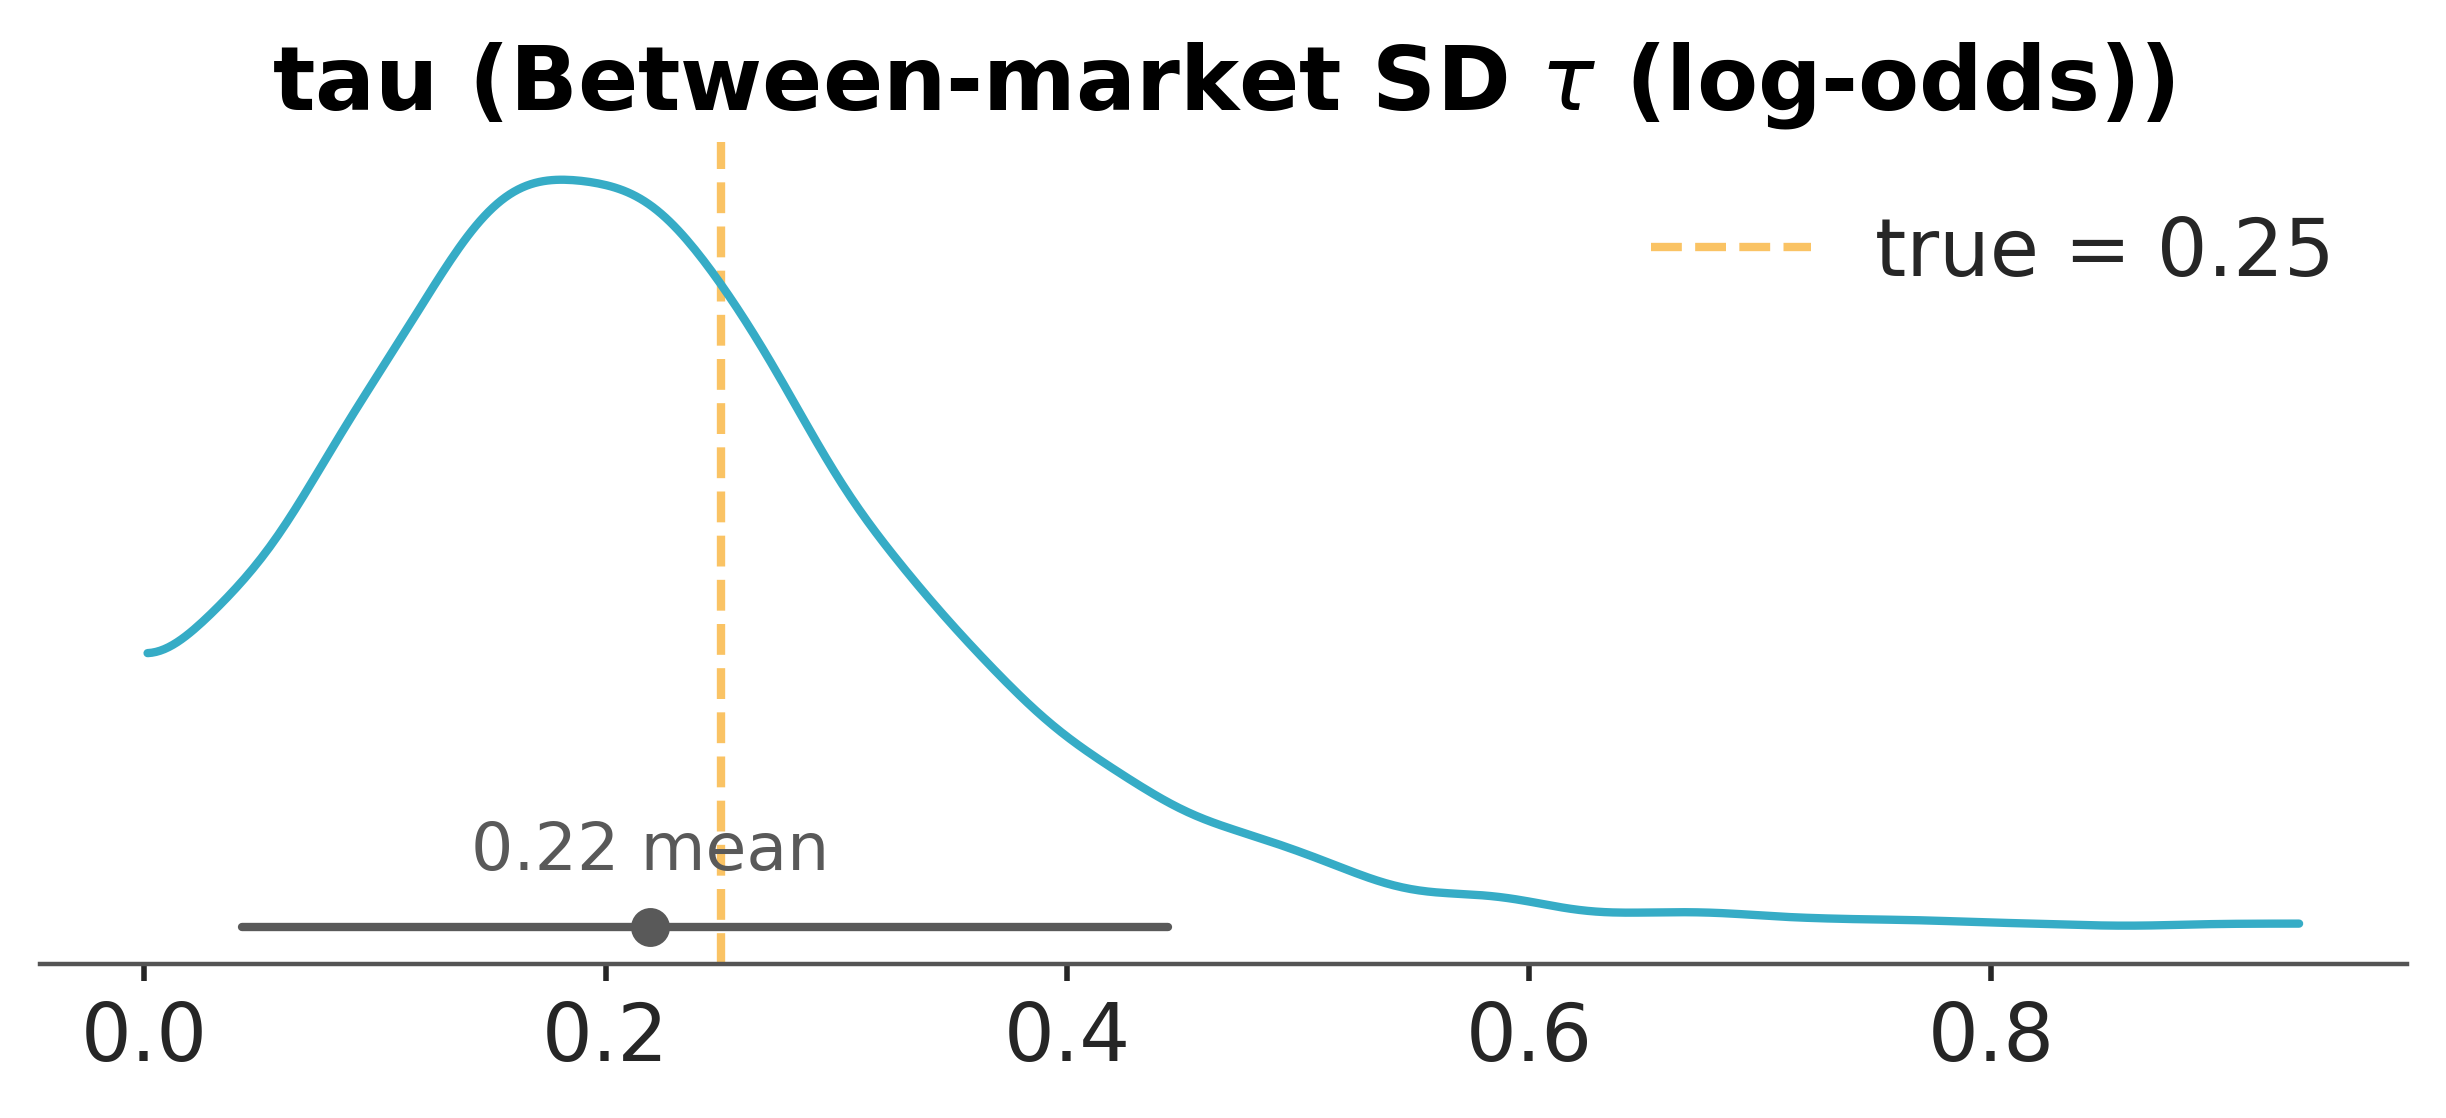

In [17]:
pc_mu = az.plot_dist(
    idata_partial_bern,
    var_names=["mu"],
    visuals={"title": {"text": r"Population log-odds effect $\mu$"}},
)
az.add_lines(
    pc_mu,
    values=TRUE_MU_LOGIT,
    visuals={"ref_line": {"color": "C2", "label": f"true = {TRUE_MU_LOGIT:.2f}"}},
)
pc_mu.get_viz("plot").legend()

pc_tau = az.plot_dist(
    idata_partial_bern,
    var_names=["tau"],
    visuals={"title": {"text": r"Between-market SD $\tau$ (log-odds)"}},
)
az.add_lines(
    pc_tau,
    values=TRUE_TAU_LOGIT,
    visuals={"ref_line": {"color": "C2", "label": f"true = {TRUE_TAU_LOGIT:.2f}"}},
)
pc_tau.get_viz("plot").legend();

The Bernoulli picture is the Gaussian picture on a different link. The population mean log-odds effect is recovered; the between-market variance is recovered; the per-market shrinkage works as before. The log-odds parameterisation carries a structural advantage the probability scale does not: a given value of τ means the same degree of between-market variability in the treatment effect regardless of what the baseline conversion rate happens to be. On the probability scale, a τ of 0.05 is meaningful heterogeneity at a 5\% baseline and negligible noise at a 50\% baseline; on the logit, τ is scale-invariant in the way the analysis needs it to be.

## How much to borrow

With $\tau$ estimated on both scales, borrowing across markets raises a question the hierarchical model answers quietly: how far should one market's estimate move toward the others. The shrinkage already shown is that answer in action. Each market's pull toward the population mean is a weight set by its own precision against the between-market variance $\tau$ the data infer.

In [18]:
tau_post_mean = float(idata_partial.posterior["tau"].mean())
shrinkage_weight = se_obs**2 / (se_obs**2 + tau_post_mean**2)
borrow_df = pd.DataFrame(
    {
        "market": MARKET_NAMES,
        "se": se_obs,
        "weight_on_population_mean": shrinkage_weight,
    }
).round(3)
borrow_df

,market,se,weight_on_population_mean
0,Market A,0.423,0.466
1,Market B,0.359,0.385
2,Market C,0.330,0.347
3,Market D,0.296,0.300
4,Market E,0.277,0.272
5,Market F,0.255,0.241
6,Market G,0.212,0.180
7,Market H,0.163,0.115


Noisy markets carry the largest weight on the population mean, so they borrow the most; precise markets keep their own estimate. The between-market variance sets the scale, and the data set $\tau$, so the borrowing rate adapts to the evidence. This is the dynamic borrowing the FDA guidance describes, where the amount borrowed responds to the similarity among the sources {cite:p}`fda2026bayesian`.

Borrowing earns its keep through precision: a prior built from real past experiments sharpens the next posterior and lowers the sample size needed to reach a given assurance, so the eight markets already run are information the ninth should use. The open question is how much of it to grant, and a *power prior* makes that dial explicit {cite:p}`ibrahim2000power`. Raise the pooled likelihood from the past markets to a discount $\alpha$ in the unit interval and use the result as the prior for the new market. With $n_0$ past subjects it contributes about $\alpha\, n_0$ observations' worth of information, so $\alpha$ is the fraction of the historical sample size carried forward, the prior effective sample size {ref}`assurance_planning` planned around. At $\alpha = 1$ the past markets count in full, as if pooled; as $\alpha$ falls toward zero the prior widens and the borrowing fades. Fixing $\alpha$ in advance is what makes the power prior the static counterpart to the hierarchical model's data-driven $\tau$.

The word *power* here means raising the likelihood to an exponent, a separate idea from the statistical power and assurance of {ref}`assurance_planning`. The two meet only through effective sample size: $\alpha$ sets how many past observations the prior is worth, and that count is the quantity the planning notebook traded against sample size.

In [19]:
w_pool = 1.0 / se_obs**2
pooled_mean = float(np.sum(w_pool * d_hat_obs) / np.sum(w_pool))
pooled_var = float(1.0 / np.sum(w_pool))

alpha_grid = np.array([0.1, 0.25, 0.5, 0.75, 1.0])
power_prior_df = pd.DataFrame(
    {"alpha": alpha_grid, "prior_mean": pooled_mean, "prior_sd": np.sqrt(pooled_var / alpha_grid)}
).round(3)
power_prior_df

,alpha,prior_mean,prior_sd
0,0.10,0.308,0.286
1,0.25,0.308,0.181
2,0.50,0.308,0.128
3,0.75,0.308,0.105
4,1.00,0.308,0.091


The power prior must be measured against the belief the hierarchical model already holds about a market it has not seen. That belief is the model's *predictive distribution*, and it comes in two forms. The true-effect predictive gives the unknown effect of a new market drawn from the same population,

$$\theta_{\text{new}} \mid \text{data} \sim \mathcal{N}\!\left(\mu_{\text{post}},\ \sqrt{\tau_{\text{post}}^2 + \sigma_{\mu,\text{post}}^2}\right),$$

and the observation predictive layers experimental noise on top,

$$\hat d_{\text{new}} \mid \text{data} \sim \theta_{\text{new}} + \mathcal{N}(0, s_{\text{new}}).$$

We draw both now. The first sets the width the power prior is chasing; the second is the yardstick for the conflict check below. The power prior borrows the precision of the pooled mean and treats every market as one draw from a single shared effect, while the hierarchical predictive folds the between-market variation back in through $\tau$. The figure sets the two side by side.

In [20]:
mu_samples = idata_partial.posterior["mu"].values.flatten()
tau_samples = idata_partial.posterior["tau"].values.flatten()
rng_pp = np.random.default_rng(RANDOM_SEED + 1)
theta_new_samples = rng_pp.normal(mu_samples, tau_samples)
s_new = np.median(se_obs)
d_hat_new_samples = theta_new_samples + rng_pp.normal(0.0, s_new, size=len(theta_new_samples))

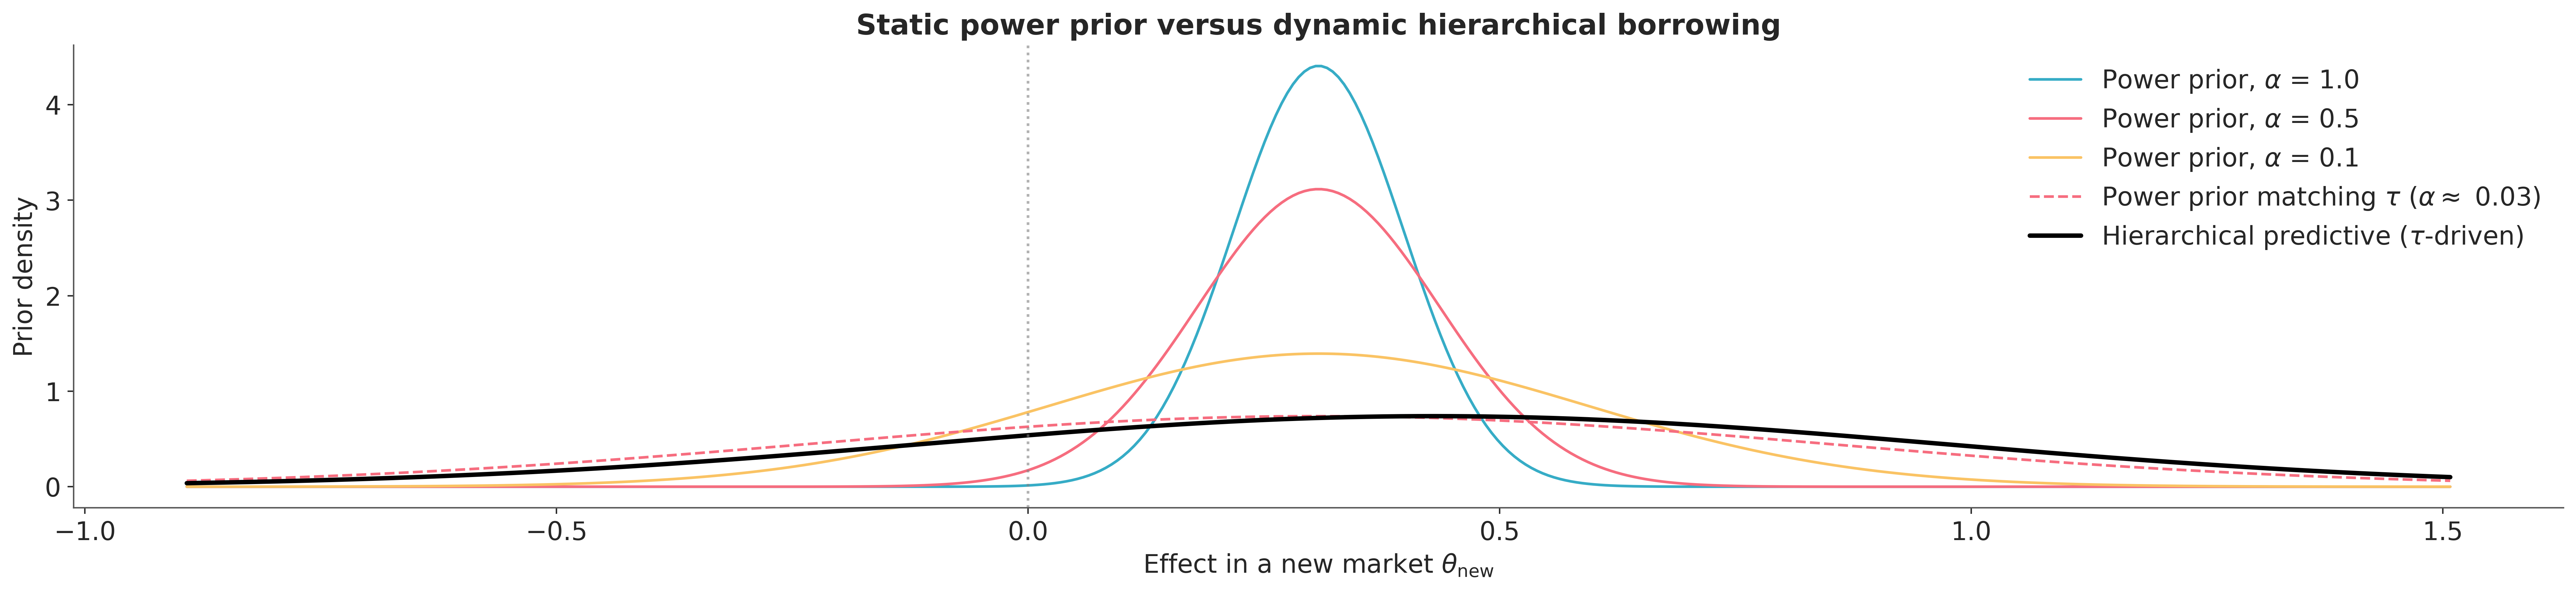

In [21]:
theta_new_mean = float(theta_new_samples.mean())
theta_new_sd = float(theta_new_samples.std())
alpha_match = (
    pooled_var / theta_new_sd**2
)  # discount at which the power prior reaches the tau-driven width
xx = np.linspace(pooled_mean - 1.2, pooled_mean + 1.2, 400)

fig, ax = plt.subplots(figsize=(20, 4.5))
for a in [1.0, 0.5, 0.1]:
    sd_a = np.sqrt(pooled_var / a)
    ax.plot(xx, stats.norm.pdf(xx, pooled_mean, sd_a), label=rf"Power prior, $\alpha$ = {a}")
ax.plot(
    xx,
    stats.norm.pdf(xx, pooled_mean, np.sqrt(pooled_var / alpha_match)),
    color="C1",
    linestyle="--",
    label=rf"Power prior matching $\tau$ ($\alpha \approx$ {alpha_match:.2f})",
)
ax.plot(
    xx,
    stats.norm.pdf(xx, theta_new_mean, theta_new_sd),
    color="black",
    linewidth=2.5,
    label=r"Hierarchical predictive ($\tau$-driven)",
)
ax.axvline(0.0, color="grey", linestyle=":", alpha=0.6)
ax.set_xlabel(r"Effect in a new market $\theta_{\text{new}}$")
ax.set_ylabel("Prior density")
ax.set_title("Static power prior versus dynamic hierarchical borrowing")
ax.legend();

At $\alpha = 1$ the static power prior is the tightest curve, far more confident about a new market than the spread across markets warrants. Matching the hierarchical predictive takes a large deviation from full borrowing: the dashed curve marks the small $\alpha$ at which the static prior finally reaches the $\tau$-driven width, and that value has to be set by hand. The hierarchical model arrives there on its own, because $\tau$ reads the between-market spread from the data.

Either prior becomes the belief the next market inherits, and that inheritance is legitimate only when the new market is drawn from the same population the past markets describe. Borrowing sharpens the posterior when that holds and pulls it toward the wrong centre when it fails, so the strength of borrowing has to be earned rather than assumed. A prior-data conflict check is the gate {cite:p}`evans2006checking`: locate the incoming estimate in the prior predictive distribution, and read a small tail probability as the new market disagreeing with the borrowed belief.

In [22]:
def prior_data_conflict_tail(d_new, prior_pred_samples):
    centre = np.median(prior_pred_samples)
    return float(np.mean(np.abs(prior_pred_samples - centre) >= abs(d_new - centre)))


concordant_d_new = 0.28  # a new market in line with the population
conflicting_d_new = -1.0  # a new market that contradicts the population
pd.DataFrame(
    {
        "incoming estimate": [concordant_d_new, conflicting_d_new],
        "prior-predictive tail probability": [
            prior_data_conflict_tail(concordant_d_new, d_hat_new_samples),
            prior_data_conflict_tail(conflicting_d_new, d_hat_new_samples),
        ],
    },
    index=["concordant market", "conflicting market"],
).round(3)

,incoming estimate,prior-predictive tail probability
concordant market,0.28,0.796
conflicting market,-1.00,0.028


The concordant market sits in the body of the predictive and the tail probability is large; the prior and the new data describe one population, so the experiment can borrow at full strength and keep the precision that buys. The conflicting market sits far out and the tail probability is small, the trigger the guidance names for reassessing how much to borrow {cite:p}`fda2026bayesian`: lower $\alpha$, widen the prior, or hold the borrowed estimate aside until the discrepancy is understood. Dynamic borrowing through $\tau$ softens this failure on its own, since a heterogeneous set of markets produces a wide predictive that absorbs a surprising estimate, while a static power prior never adapts, so the analyst must run the check every time. Whatever borrowing strength passes the check is the prior the next experiment plans with.

## Predicting the next experiment

The predictive we drew to calibrate borrowing also answers the question that occasioned the whole exercise: what will happen if we run the redesign in a market we have not tested yet. The two flavours now do decision work. The true-effect predictive $\theta_{\text{new}}$ is the best estimate of the effect in a new market; the observation predictive $\hat d_{\text{new}}$ is what to expect the next experiment to actually return, noise included. The gap between them is the experimental-noise envelope that a single-market estimate conflates with population variation.

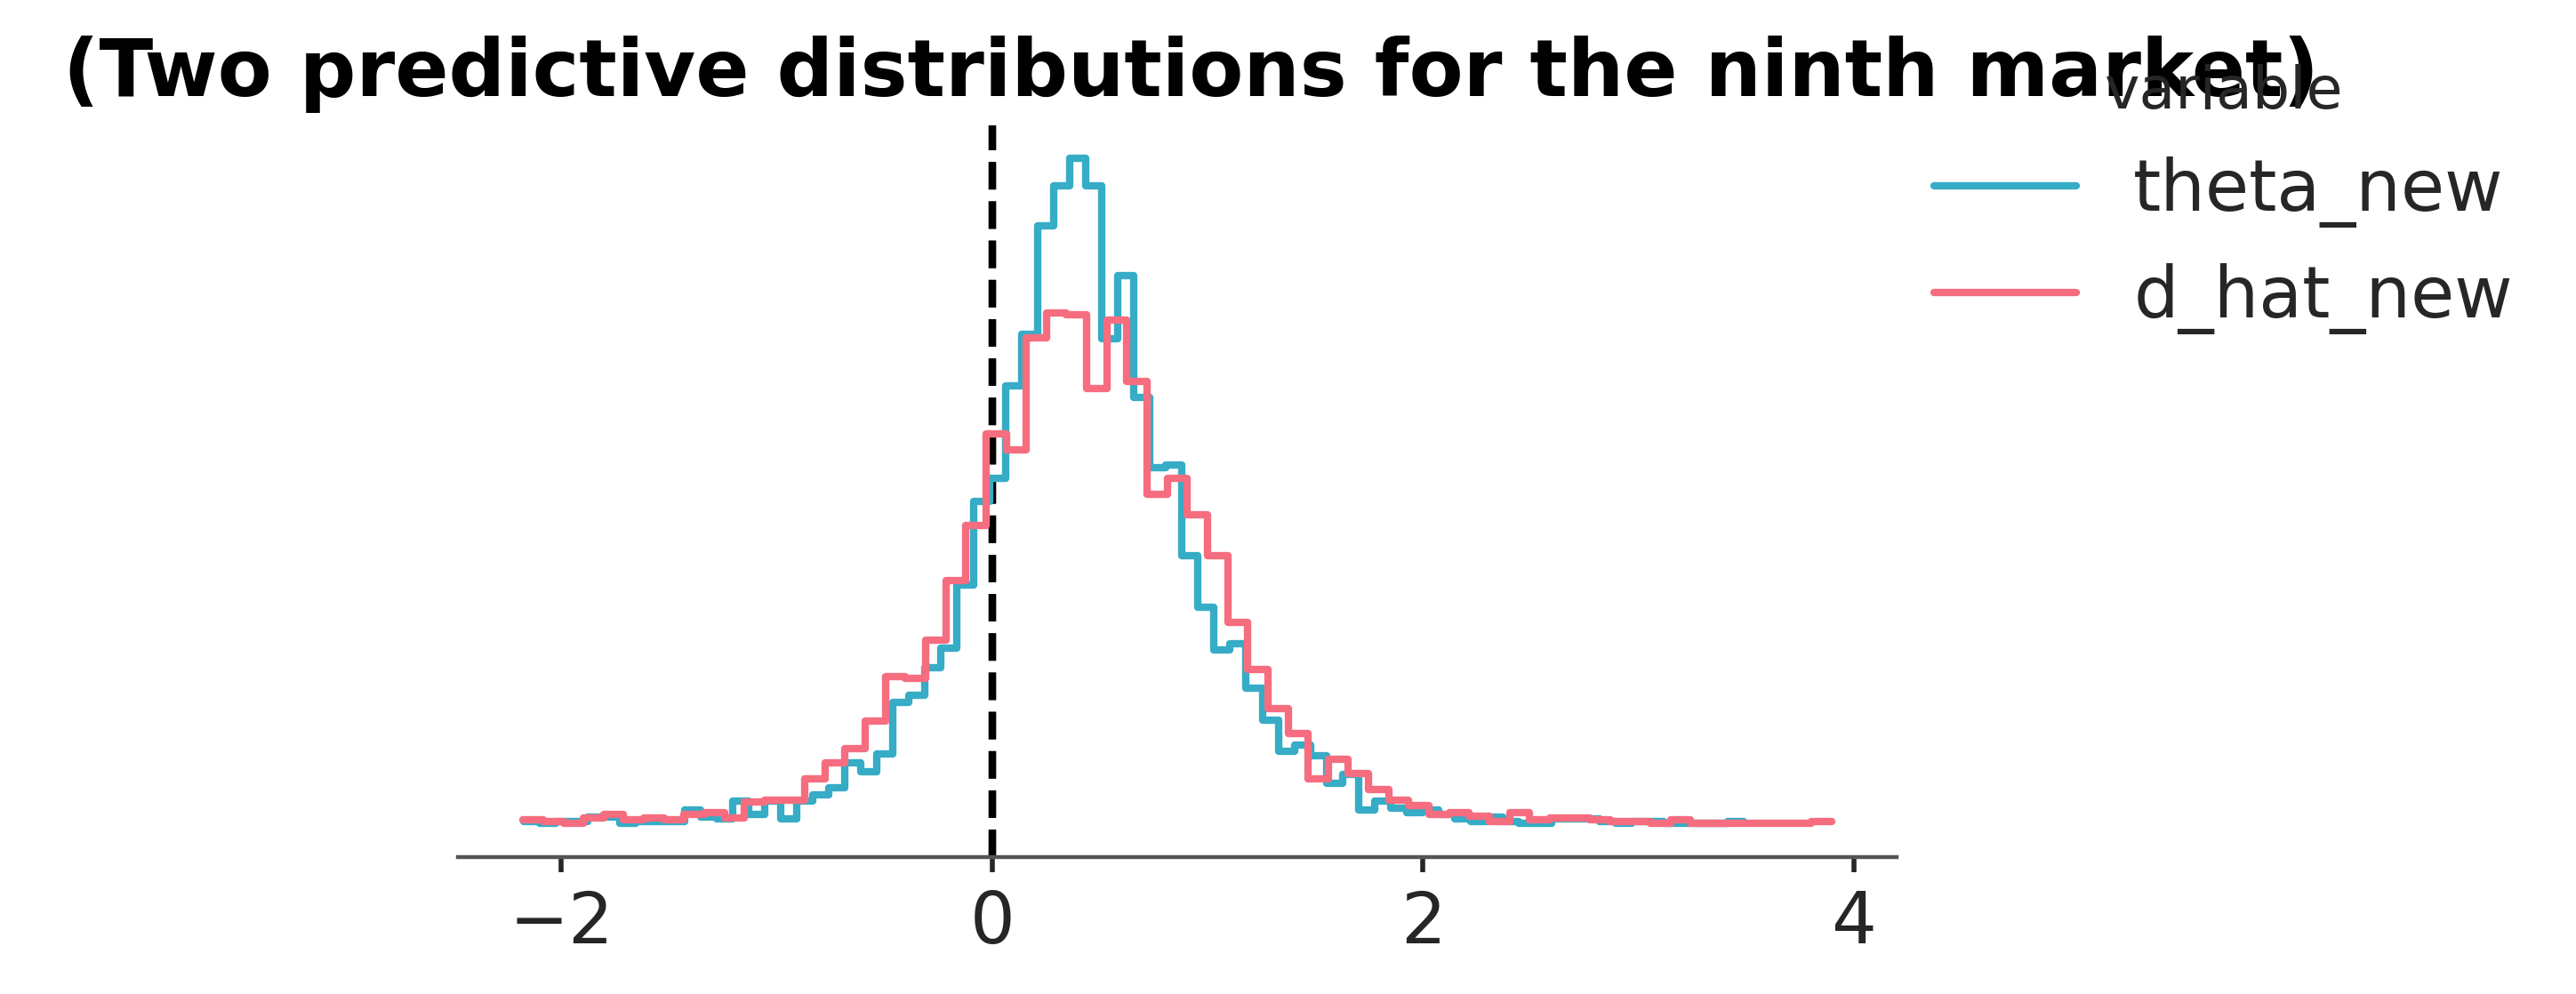

In [23]:
dt = az.from_dict(
    {
        "posterior": {
            "theta_new": theta_new_samples,
            "d_hat_new": d_hat_new_samples,
        }
    },
    sample_dims=["sample"],
)

pc = az.plot_dist(
    dt,
    kind="hist",
    sample_dims=["sample"],
    cols=[],
    aes={"color": ["__variable__"]},
    visuals={
        "point_estimate": False,
        "point_estimate_text": False,
        "credible_interval": False,
        "title": {"text": "Two predictive distributions for the ninth market"},
    },
)
pc.add_legend("__variable__")
az.add_lines(pc, values=0.0, visuals={"ref_line": {"color": "black", "label": "0"}});

In [24]:
prob_theta_new_positive = float((theta_new_samples > 0).mean())
prob_d_hat_new_positive = float((d_hat_new_samples > 0).mean())
pd.DataFrame(
    {"posterior probability > 0": [prob_theta_new_positive, prob_d_hat_new_positive]},
    index=[r"$\theta_{\text{new}}$ (true effect)", r"$\hat d_{\text{new}}$ (observed estimate)"],
).round(3)

,posterior probability > 0
$\theta_{\text{new}}$ (true effect),0.825
$\hat d_{\text{new}}$ (observed estimate),0.784


The probability the true effect is positive in the next market is higher than the probability the next experiment will return a positive estimate. The gap is the experimental-noise tax: each individual experiment is a noisy realisation of an underlying truth, and the team will sometimes see a negative estimate even when the true effect is positive. Reporting the meta-analytic posterior on $\theta_{\text{new}}$ as the planning input for the next market, which {ref}`assurance_planning` then consumes as its prior, is the way to feed accumulating evidence forward without losing track of the noise.

## The synthesis becomes the next plan

The predictive that calibrated borrowing also answers the question the planning notebook opens with. Read off its centre and width and the loop is closed explicitly: this synthesis is the prior {ref}`assurance_planning` integrates over.

In [25]:
# The true-effect predictive is exactly what the planning notebook treats as its
# prior: a Normal summarised by a location and a width.
planning_mu = round(float(theta_new_mean), 1)
planning_sigma = round(float(theta_new_sd), 1)
assurance_ceiling_next = 1.0 - stats.norm.cdf(0.0, planning_mu, planning_sigma)

pd.DataFrame(
    {"value": [planning_mu, planning_sigma, round(float(assurance_ceiling_next), 3)]},
    index=[
        "planning prior mean  μ",
        "planning prior sd    σ",
        "assurance ceiling  P(θ_new > 0)",
    ],
)

,value
planning prior mean μ,0.400
planning prior sd σ,0.500
assurance ceiling P(θ_new > 0),0.788


`EffectPrior(mu=planning_mu, sigma=planning_sigma)` is the object {ref}`assurance_planning` opens with.

## Replication as the data-generating process

A single experiment is overheard speech. Eight experiments are conversation. The hierarchical model is what lets us hear them as conversation, and the posterior on the population describes the very population our experiments were drawn from.

Replication is often described as a verification protocol, a post-hoc check on a result already in hand. It is better understood as the data-generating process whose distribution we are trying to learn. Each new market is a draw from a population we never observed directly; pooling constructs that population from the draws; the next experiment tests whether the constructed population keeps predicting new markets. The three notebooks make the same move on three problems. Planning became a posterior over the posteriors a future experiment will compute. Interpretation became a posterior over the bias a single experiment cannot rule out. Synthesis became a posterior over the population a series of experiments samples from. The likelihood changed from Gaussian to Bernoulli each time and the picture held. In each, an assumption a conventional analysis leaves implicit is made a parameter with a posterior, something to argue about rather than assume. The problem changes; its proper characterisation is always a posterior.

And the last question feeds the first. The population this notebook inferred is the prior the planning notebook consumes: $\theta_{\text{new}} \sim \mathcal{N}(\mu, \tau)$ is the kind of belief {ref}`assurance_planning` integrates over before the next experiment is run. The synthesis that ends one experiment's lifecycle is the input to the design of the next. The lifecycle runs as a loop rather than a line from plan to verdict, and the posterior is what travels around it: each notebook's synthesis becomes the next notebook's prior, and each overheard conversation becomes the next one's opening question.

## Authors

- Authored by [Nathaniel Forde](https://nathanielf.github.io/) in May 2026.

## References

:::{bibliography}
:filter: docname in docnames
:::

## Watermark

In [26]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pytensor,xarray

Last updated: Mon, 29 Jun 2026

Python implementation: CPython
Python version       : 3.13.13
IPython version      : 9.14.0

pytensor: 3.0.3
xarray  : 2026.4.0

arviz     : 1.1.0
matplotlib: 3.10.9
numpy     : 2.3.5
pandas    : 2.3.3
pymc      : 6.0.1
scipy     : 1.17.1

Watermark: 2.6.0



:::{include} ../page_footer.md
:::